###Data Preprocessing

###I. Data Cleaning

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Master data
products = pd.read_csv("../data/products.csv")
customers = pd.read_csv("../data/customers.csv")
promotions = pd.read_csv("../data/promotions.csv")
geography = pd.read_csv("../data/geography.csv")

# Transaction data
# Explicitly define the promo columns as strings to fix the DtypeWarning
orders = pd.read_csv("../data/orders.csv")
order_items = pd.read_csv("../data/order_items.csv", dtype={'promo_id': str, 'promo_id_2':str})
payments = pd.read_csv("../data/payments.csv")
shipments = pd.read_csv("../data/shipments.csv")
returns = pd.read_csv("../data/returns.csv")
reviews = pd.read_csv("../data/reviews.csv")

# Analytical
sales = pd.read_csv("../data/sales.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

# Operational data
inventory = pd.read_csv("../data/inventory.csv")
web_traffic = pd.read_csv("../data/web_traffic.csv")

In [ ]:
# Detect abnormal data

print("Checking business logic violations")

# 1. Check for Pricing Constraint Violations
pricing_anomalies = products[products['cogs'] >= products['price']]

if not pricing_anomalies.empty:
    print(f"Found {len(pricing_anomalies)} products where COGS is greater than or equal to Price.")
    display(pricing_anomalies)
    # Action: You might need to drop these, or investigate if COGS and Price were accidentally swapped.
else:
    print("All products pass the COGS < Price constraint.")

# 2. Check for Timeline Anomalies
# MMerge orders and shipments to compare dates
timeline_check = pd.merge(shipments, orders[['order_id', 'order_date']], on='order_id', how='left')

# Flag 1: Shipped before ordered
shipped_early = timeline_check[timeline_check['ship_date'] < timeline_check['order_date']]

# Flag 2: Delivered before shipped
delivered_early = timeline_check[timeline_check['delivery_date'] < timeline_check['ship_date']]

print(f"Orders shipped before placement: {len(shipped_early)}")
print(f"Orders delivered before shipping: {len(delivered_early)}")

# 3. Check for Financial and Quantity Anomalies in Order Items

# Flag negative quantities or prices
negative_qty = order_items[order_items['quantity'] <= 0]
negative_price = order_items[order_items['unit_price'] <= 0]

# Flag impossible discounts (discount amount > unit_price * quantity)
# Assuming unit_price is BEFORE discount based on standard schema, but you should verify this during EDA.
absurd_discounts = order_items[order_items['discount_amount'] > (order_items['unit_price'] * order_items['quantity'])]

print(f"Items with zero/negative quantity: {len(negative_qty)}")
print(f"Items with zero/negative price: {len(negative_price)}")
print(f"Items with discounts larger than item value: {len(absurd_discounts)}")

# Action: Drop rows with negative quantities or prices. Cap absurd discounts to the max item value.

# 4. Check for Orphaned Records
# Are there orders from customers that don't exist in the master table?
valid_customers = set(customers['customer_id'])
orphaned_orders = orders[~orders['customer_id'].isin(valid_customers)]

# Are there order items for products that don't exist in the master table?
valid_products = set(products['product_id'])
orphaned_items = order_items[~order_items['product_id'].isin(valid_products)]

print(f"Orders with missing customer profiles: {len(orphaned_orders)}")
print(f"Order items with missing product catalogs: {len(orphaned_items)}")

# Drop or fill their missing demographic features with 'Unknown'.

print("-----------------------------------------------------------------")
print("Null detection report")
# ==========================================
# NULL DETECTION REPORT
# ==========================================

# Create a dictionary of all your loaded dataframes
all_datasets = {
    "Products": products, "Customers": customers, "Promotions": promotions, "Geography": geography,
    "Orders": orders, "Order Items": order_items, "Payments": payments, "Shipments": shipments,
    "Returns": returns, "Reviews": reviews, "Sales": sales,
    "Inventory": inventory, "Web Traffic": web_traffic
}

print("=== SYSTEM WIDE NULL REPORT ===")
clean_tables = []

for name, df in all_datasets.items():
    # Calculate nulls per column
    null_counts = df.isnull().sum()

    # Filter only columns that actually have nulls
    null_cols = null_counts[null_counts > 0]

    if not null_cols.empty:
        print(f"\n[{name}] has missing values:")
        for col, count in null_cols.items():
            # Calculate the percentage of missing data
            percent = (count / len(df)) * 100
            print(f"  -> {col}: {count} rows missing ({percent:.2f}%)")
    else:
        clean_tables.append(name)

print("\n=== CLEAN TABLES (No Nulls) ===")
print(", ".join(clean_tables))

Checking business logic violations
All products pass the COGS < Price constraint.
Orders shipped before placement: 0
Orders delivered before shipping: 0
Items with zero/negative quantity: 0
Items with zero/negative price: 0
Items with discounts larger than item value: 0
Orders with missing customer profiles: 0
Order items with missing product catalogs: 0
-----------------------------------------------------------------
Null decection report
=== SYSTEM WIDE NULL REPORT ===

[Promotions] has missing values:
  -> applicable_category: 40 rows missing (80.00%)

[Order Items] has missing values:
  -> promo_id: 438353 rows missing (61.34%)
  -> promo_id_2: 714463 rows missing (99.97%)

=== CLEAN TABLES (No Nulls) ===
Products, Customers, Geography, Orders, Payments, Shipments, Returns, Reviews, Sales, Inventory, Web Traffic


### Stage 1: Datetime Formatting

In [ ]:
# Master data

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Transaction data

orders['order_date'] = pd.to_datetime(orders['order_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

# Analytical & Operational data

sales['Date'] = pd.to_datetime(sales['Date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])




### Stage 2: Null Handling

In [ ]:
# A null applicable_category means it applies to all categories
promotions['applicable_category'] = promotions['applicable_category'].fillna('All_Categories')

# A null promo_id means no discount was applied
order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('No_Promo')

print("Imputation complete. All nulls handled safely.")
#print(promotions['applicable_category'])

Imputation complete. All nulls handled safely.


### Checking for the conformity values in dataset

In [ ]:
# CATEGORICAL INCONSISTENCY REPORT
print("---CATEGORICAL VALUE AUDIT---")

# Check a few key tables for weird text values
tables_to_check = {'Customers': customers, 'Products': products, 'Orders': orders}

for name, df in tables_to_check.items():
    print(f"\n--- {name} ---")
    # Select only columns containing text (object/string type)
    text_columns = df.select_dtypes(include=['object']).columns

    for col in text_columns:
        # Get the unique values and their counts
        value_counts = df[col].value_counts(dropna=False)

        # If a column has too many unique values (like a Name or ID), skip it to avoid flooding the screen. We only care about categories.
        if len(value_counts) < 50:
            print(f"\nColumn: '{col}'")
            print(value_counts)
        else:
            print(f"\nColumn: '{col}' - Skipped (Too many unique values: {len(value_counts)})")
# NUMERICAL OUTLIER REPORT
print("=== NUMERICAL OUTLIER AUDIT ===")

# Let's look at the actual transactions
print("\n--- Order Items Summary ---")
# The .describe() function gives you the Min, Max, and Percentiles
display(order_items[['quantity', 'unit_price', 'discount_amount']].describe())

print("\n--- Payments Summary ---")
display(payments[['payment_value', 'installments']].describe())

---CATEGORICAL VALUE AUDIT---

--- Customers ---

Column: 'city'
city
Cam Pha                4398
Thai Nguyen            4347
Phu Ly                 4243
Hanoi                  4240
Ha Long                4236
Bac Ninh               4172
Hai Phong              4170
Nam Dinh               4169
Bac Giang              4160
Ninh Binh              4081
Son Tay                4075
Viet Tri               4054
Uong Bi                4026
Dong Hoi               3912
Kon Tum                3838
Lao Cai                3807
Hoi An                 3760
Phan Thiet             3749
Phan Rang-Thap Cham    3734
Hue                    3719
Tuy Hoa                3674
Quang Ngai             3616
Da Nang                3616
Tam Ky                 3562
Quy Nhon               3556
Nha Trang              3550
Ho Chi Minh City       1359
Vinh Long              1336
Pleiku                 1253
Vung Tau               1251
Da Lat                 1243
Can Tho                1214
Bac Lieu               1211
Ca Mau

/tmp/ipykernel_14820/4149162049.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns
/tmp/ipykernel_14820/4149162049.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dt


order_source
organic_search    181495
paid_search       141652
social_media      129710
email_campaign     77572
referral           64565
direct             51951
Name: count, dtype: int64
=== NUMERICAL OUTLIER AUDIT ===

--- Order Items Summary ---


,quantity,unit_price,discount_amount
count,714669.000000,714669.000000,714669.000000
mean,4.495988,5114.690157,1048.887415
std,2.290143,3774.817912,2280.530606
min,1.000000,392.570000,0.000000
25%,2.000000,1906.890000,0.000000
50%,4.000000,4257.770000,0.000000
75%,6.000000,7273.760000,967.630000
max,8.000000,43056.000000,35235.470000



--- Payments Summary ---


,payment_value,installments
count,646945.000000,646945.000000
mean,24238.334426,3.448319
std,22378.475324,3.119582
min,389.740000,1.000000
25%,7681.060000,1.000000
50%,17229.440000,3.000000
75%,33706.350000,6.000000
max,331570.400000,12.000000


### *Post-Cleaning Null Verification*
Checking if any null values remain across all processed DataFrames.

In [ ]:
# Re-evaluating the datasets after imputation
all_datasets = {
    "Products": products, "Customers": customers, "Promotions": promotions, "Geography": geography,
    "Orders": orders, "Order Items": order_items, "Payments": payments, "Shipments": shipments,
    "Returns": returns, "Reviews": reviews, "Sales": sales,
    "Inventory": inventory, "Web Traffic": web_traffic
}

print("=== SYSTEM WIDE NULL REPORT (POST-CLEANING) ===")
any_nulls = False

for name, df in all_datasets.items():
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]

    if not null_cols.empty:
        any_nulls = True
        print(f"\n[{name}] still has missing values:")
        for col, count in null_cols.items():
            print(f"  -> {col}: {count} rows")

if not any_nulls:
    print("\nSuccess: All datasets are clean. No null values found.")
else:
    print("\nWarning: Some null values still persist. Please review the report above.")

=== SYSTEM WIDE NULL REPORT (POST-CLEANING) ===

Success: All datasets are clean. No null values found.


###II. EDA

###EDA Test

/tmp/ipykernel_14820/3234025551.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=macro_data_zoomed, x='Year', y='total_orders', ax=ax2, palette=colors_orders, legend=False, edgecolor='black')


✓ File PNG đã được lưu: vietnamese_macro_market_story.png


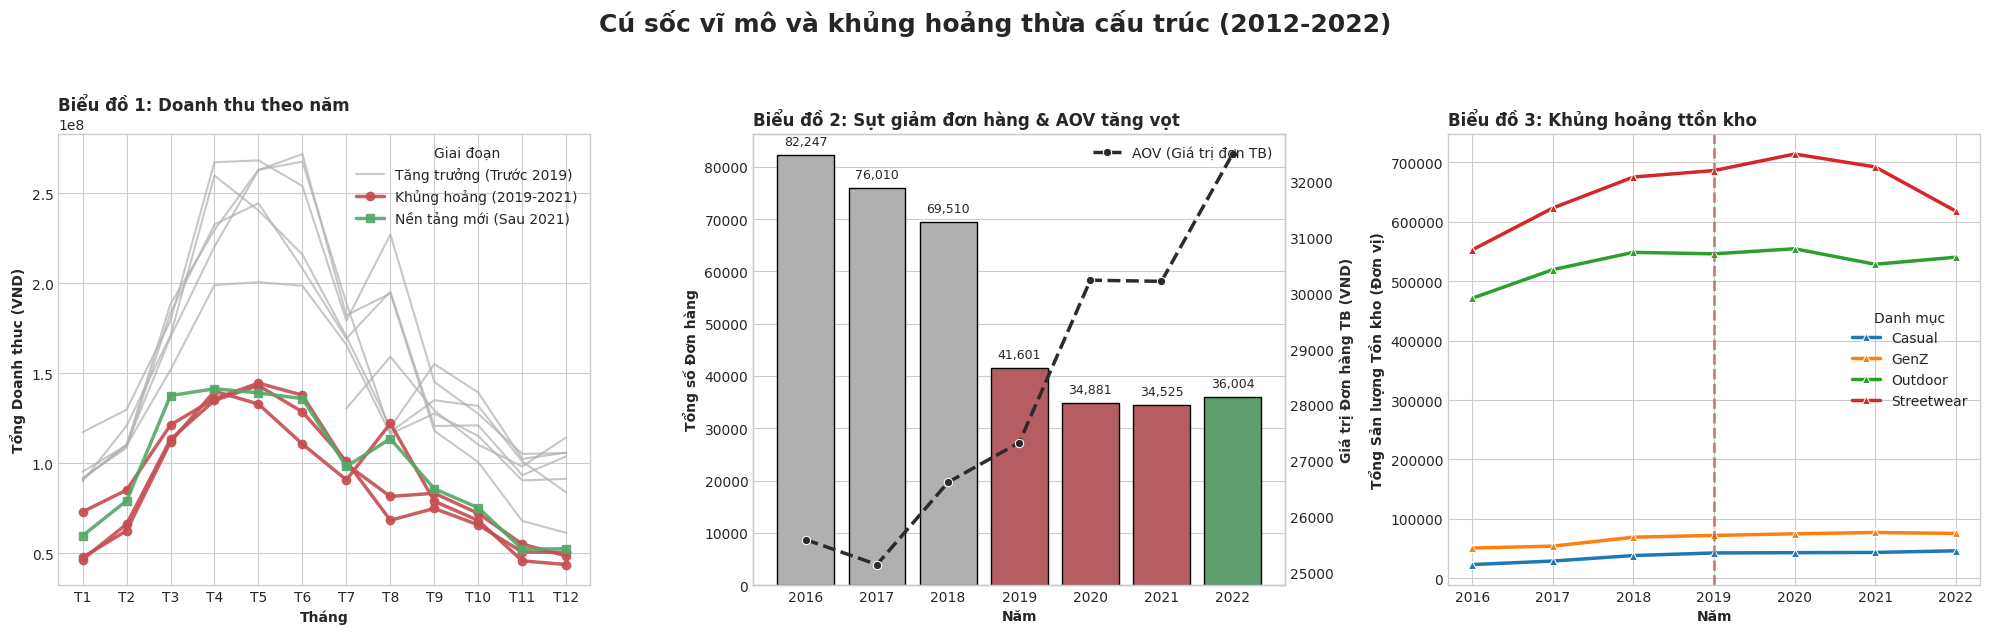

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def generate_vietnamese_macro_market_story_plot():
    # 1. CHUẨN BỊ DỮ LIỆU
    try:
        sales = pd.read_csv('data/sales.csv')
        orders = pd.read_csv('data/orders.csv')
        inventory = pd.read_csv('data/inventory.csv')
        products = pd.read_csv('data/products.csv')
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file CSV. {e}")
        return

    inventory.columns = inventory.columns.str.lower()
    products.columns = products.columns.str.lower()
    sales['Date'] = pd.to_datetime(sales['Date'])
    orders['order_date'] = pd.to_datetime(orders['order_date'])

    # CHART 1: Doanh thu theo tháng
    sales['YearMonth'] = sales['Date'].dt.to_period('M')
    monthly_sales = sales.groupby('YearMonth')['Revenue'].sum().reset_index()
    monthly_sales['Date'] = monthly_sales['YearMonth'].dt.to_timestamp()
    monthly_sales['Year'] = monthly_sales['Date'].dt.year
    monthly_sales['Month'] = monthly_sales['Date'].dt.month

    # CHART 2: Lượng đơn & AOV
    sales['Year'] = sales['Date'].dt.year
    orders['Year'] = orders['order_date'].dt.year
    yearly_sales = sales.groupby('Year')['Revenue'].sum().reset_index()
    yearly_orders = orders.groupby('Year')['order_id'].nunique().reset_index().rename(columns={'order_id': 'total_orders'})
    macro_data = pd.merge(yearly_sales, yearly_orders, on='Year', how='inner')
    macro_data['AOV'] = macro_data['Revenue'] / macro_data['total_orders']
    macro_data_zoomed = macro_data[macro_data['Year'].between(2016, 2022)].reset_index(drop=True)

    # PANEL 3 DATA: Tồn kho
    if 'snapshot_date' in inventory.columns:
        inventory['year'] = pd.to_datetime(inventory['snapshot_date']).dt.year
    elif 'date' in inventory.columns:
        inventory['year'] = pd.to_datetime(inventory['date']).dt.year

    inventory_zoomed = inventory[inventory['year'].between(2016, 2022)].copy()
    if 'category' in inventory_zoomed.columns:
        inventory_zoomed = inventory_zoomed.drop(columns=['category'])

    inv_prod = inventory_zoomed.merge(products[['product_id', 'category']], on='product_id', how='inner')
    qty_col = next((col for col in ['stock_on_hand', 'quantity', 'stock_quantity'] if col in inv_prod.columns), None)
    if qty_col:
        stock_qty = inv_prod.groupby(['year', 'category'])[qty_col].sum().reset_index()

    # 2. CẤU HÌNH PLOT (TIẾNG VIỆT)
    plt.style.use('seaborn-v0_8-whitegrid')

    # Ép phông chữ DejaVu Sans
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Cú sốc vĩ mô và khủng hoảng thừa cấu trúc (2012-2022)', fontsize=18, fontweight='bold', y=1.05)

    # CHART 1: DOANH THU THEO NĂM (SHOW 3 GIAI ĐOẠN)
    ax1 = axes[0]

    # Biến kiểm soát để chỉ thêm chú giải (legend) 1 lần cho mỗi nhóm
    legend_added = {'Phase 1': False, 'Phase 2': False, 'Phase 3': False}

    for year in range(2012, 2023):
        year_data = monthly_sales[monthly_sales['Year'] == year]
        if year_data.empty: continue

        # Phân loại nhóm theo màu sắc
        if year <= 2018:
            color = '#b0b0b0' # Xám nhạt
            alpha = 0.7
            linewidth = 1.5
            marker = None
            label = 'Tăng trưởng (Trước 2019)' if not legend_added['Phase 1'] else "_nolegend_"
            legend_added['Phase 1'] = True
        elif year <= 2021:
            color = '#c44e52' # Đỏ đậm
            alpha = 0.9
            linewidth = 2.5
            marker = 'o'
            label = 'Khủng hoảng (2019-2021)' if not legend_added['Phase 2'] else "_nolegend_"
            legend_added['Phase 2'] = True
        else:
            color = '#55a868' # Xanh lá
            alpha = 0.9
            linewidth = 2.5
            marker = 's'
            label = 'Nền tảng mới (Sau 2021)' if not legend_added['Phase 3'] else "_nolegend_"
            legend_added['Phase 3'] = True

        ax1.plot(year_data['Month'], year_data['Revenue'], color=color, alpha=alpha,
                 linewidth=linewidth, marker=marker, label=label)

    ax1.set_title('Biểu đồ 1: Doanh thu theo năm', fontweight='bold', loc='left')
    ax1.set_xlabel('Tháng', fontweight='bold')
    ax1.set_ylabel('Tổng Doanh thuc (VND)', fontweight='bold')

    # Đổi tên nhãn X thành tháng
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12'])
    ax1.legend(title='Giai đoạn', loc='upper right')

    # PANEL 2: ĐƠN HÀNG VS AOV
    ax2 = axes[1]
    macro_data_zoomed['Hue'] = macro_data_zoomed['Year'].astype(str)

    # Tô màu cột đồng bộ với Phase (Xám -> Đỏ -> Xanh)
    colors_orders = ['#b0b0b0' if y <= 2018 else '#c44e52' if y <= 2021 else '#55a868' for y in macro_data_zoomed['Year']]

    sns.barplot(data=macro_data_zoomed, x='Year', y='total_orders', ax=ax2, palette=colors_orders, legend=False, edgecolor='black')

    for p in ax2.patches:
        height = p.get_height()
        if height > 0:
            ax2.annotate(f'{int(height):,}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9)

    ax2_twin = ax2.twinx()
    sns.lineplot(x=np.arange(len(macro_data_zoomed)), y=macro_data_zoomed['AOV'], ax=ax2_twin, color='#2b2b2b', linewidth=2.5, linestyle='--', marker='o', label='AOV (Giá trị đơn TB)')

    ax2.set_title('Biểu đồ 2: Sụt giảm đơn hàng & AOV tăng vọt', fontweight='bold', loc='left')
    ax2.set_xlabel('Năm', fontweight='bold')
    ax2.set_ylabel('Tổng số Đơn hàng', fontweight='bold')
    ax2_twin.set_ylabel('Giá trị Đơn hàng TB (VND)', fontweight='bold', color='#2b2b2b')
    ax2_twin.grid(False)
    ax2_twin.legend(loc='upper right')

    # PANEL 3: KHỦNG HOẢNG TỒN KHO
    ax3 = axes[2]
    if qty_col:
        sns.lineplot(data=stock_qty, x='year', y=qty_col, hue='category', marker='^', ax=ax3, linewidth=2.5)
        ax3.set_title('Biểu đồ 3: Khủng hoảng ttồn kho', fontweight='bold', loc='left')
        ax3.set_xlabel('Năm', fontweight='bold')
        ax3.set_ylabel('Tổng Sản lượng Tồn kho (Đơn vị)', fontweight='bold')

        ax3.axvline(x=2019, color='#c44e52', linestyle='--', alpha=0.7, linewidth=2)
        ax3.legend(title='Danh mục')

    plt.tight_layout()
    plt.savefig('vietnamese_macro_market_story.png', dpi=300, bbox_inches='tight')
    print("✓ File PNG đã được lưu: vietnamese_macro_market_story.png")
    plt.show()

generate_vietnamese_macro_market_story_plot()